# Debug Loss — α and β₉₀ sensitivity

This notebook exposes intermediate recombination quantities (ξ(φ), β_eff(φ), R, Q, L)
and full Sobolev losses as functions of `alpha` and `beta_90`.

Cells 1-5 set up the simulator and define helper functions.  
**Start from cell 6** to vary the parameters yourself.

In [1]:
import sys; sys.path.insert(0, '..')

from dotenv import load_dotenv; load_dotenv()

import os
import time

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from tools.geometry import generate_detector
from tools.loader import build_deposit_data
from tools.losses import make_sobolev_weight, sobolev_loss, sobolev_loss_geomean_log1p
# from tools.particle_generator import generate_muon_track
from tools.recombination import _xi_emb, compute_quanta, XI_FN
from tools.simulation import DetectorSimulator

_JAX_CACHE_DIR = os.path.expanduser('~/.cache/jax_compilation_cache')
jax.config.update('jax_compilation_cache_dir', _JAX_CACHE_DIR)
jax.config.update('jax_persistent_cache_min_compile_time_secs', 1.0)

print(f'JAX devices: {jax.devices()}')

JAX devices: [CudaDevice(id=0)]


E0420 12:07:55.873464    3867 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )
E0420 12:07:55.892380    1504 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )


In [2]:
# ── Configuration ──────────────────────────────────────────────────────────────
CONFIG_PATH        = '../config/cubic_wireplane_config.yaml'
N_SEGMENTS         = 10_000
MAX_ACTIVE_BUCKETS = 1000
DETECTOR_BOUNDS_MM = ((-300, 300), (-300, 300), (-300, 300))
SOBOLEV_MAX_PAD    = 128

GT_LIFETIME_US    = 10_000.0
GT_VELOCITY_CM_US = 0.160

# Muon track used as the "measurement"
DIRECTION    = (1, 1, 1)   # diagonal
MOMENTUM_MEV = 1000.0

In [3]:
# ── Build simulator and deposits ───────────────────────────────────────────────
print('Building differentiable simulator...')
detector_config = generate_detector(CONFIG_PATH)

simulator = DetectorSimulator(
    detector_config,
    differentiable=True,
    n_segments=N_SEGMENTS,
    use_bucketed=True,
    max_active_buckets=MAX_ACTIVE_BUCKETS,
    include_noise=False,
    include_electronics=False,
    include_track_hits=False,
    include_digitize=False,
)

assert simulator.recomb_model == 'emb', (
    f'This notebook targets the EMB model; got {simulator.recomb_model!r}')

print(f'Generating muon track  direction={DIRECTION}  T={MOMENTUM_MEV} MeV...')
track = generate_muon_track(
    start_position_mm=(0.0, 0.0, 0.0),
    direction=DIRECTION,
    kinetic_energy_mev=MOMENTUM_MEV,
    step_size_mm=0.1,
    track_id=1,
    detector_bounds_mm=DETECTOR_BOUNDS_MM,
)

# phi_drift = angle between track direction and drift E-field (x-axis, no SCE)
# cos(phi_drift) = |track · E_hat| = |sin(theta) * cos(phi)|
track['phi_drift'] = np.arccos(
    np.abs(np.sin(track['theta']) * np.cos(track['phi']))
)

deposits = build_deposit_data(
    track['position'], track['de'], track['dx'], simulator.config,
    theta=track['theta'], phi=track['phi'],
    track_ids=track['track_id'],
)
n_total = sum(v.n_actual for v in deposits.volumes)
print(f'Generated {n_total:,} deposits')
print(f'Track phi_drift = {np.degrees(track["phi_drift"][0]):.2f}°  '
      f'(track azimuthal phi = {np.degrees(track["phi"][0]):.2f}°)')

print('Warming up JIT (may take ~60 s)...')
t0 = time.time()
simulator.warm_up()
print(f'Done ({time.time() - t0:.1f} s)')

Building differentiable simulator...
--- Creating DetectorSimulator ---
   Extracting parameters...
   Loading response kernels...
   Space charge effects: DISABLED
   Recombination model: emb
   Config: total_pad=10,000, response_chunk=10,000, num_s=16, K_wire=2, K_time=6
   Track labeling: DISABLED
   Readout: wire
   Volumes: 2 (iterate=scan)
--- DetectorSimulator Ready ---
Generating muon track  direction=(1, 1, 1)  T=1000.0 MeV...


NameError: name 'generate_muon_track' is not defined

In [ ]:
# ── Ground-truth params and Sobolev weights ────────────────────────────────────
gt_params = simulator.default_sim_params._replace(
    lifetime_us    = jnp.array(GT_LIFETIME_US),
    velocity_cm_us = jnp.array(GT_VELOCITY_CM_US),
)
rp_gt = gt_params.recomb_params

print(f'GT alpha   = {float(rp_gt.alpha):.4f}')
print(f'GT beta_90 = {float(rp_gt.beta_90):.4f}')
print(f'GT R       = {float(rp_gt.R):.4f}')

print('Computing GT forward pass and Sobolev weights...')
gt_arrays = simulator.forward(gt_params, deposits)
jax.block_until_ready(gt_arrays)

sobolev_weights = tuple(
    make_sobolev_weight(arr.shape[0], arr.shape[1], max_pad=SOBOLEV_MAX_PAD)
    for arr in gt_arrays
)
print(f'Done — {len(gt_arrays)} plane arrays')

GT alpha   = 0.9040
GT beta_90 = 0.2040
GT R       = 1.2500
Computing GT forward pass and Sobolev weights...


W0419 23:40:20.893325   30946 pjrt_executable.cc:642] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


Done — 6 plane arrays


In [ ]:
# ── Helper functions ───────────────────────────────────────────────────────────

def make_params(alpha, beta_90):
    """Return SimParams with alpha and beta_90 replaced."""
    rp = rp_gt._replace(
        alpha=jnp.array(float(alpha)),
        beta_90=jnp.array(float(beta_90)),
    )
    return gt_params._replace(recomb_params=rp)


def _extract_deposits():
    """Concatenate real deposits across all volumes. Returns (de, dx_cm, theta, phi)."""
    de, dx, theta, phi = [], [], [], []
    for vol in deposits.volumes:
        n = vol.n_actual
        de.append(np.array(vol.de[:n]))
        dx.append(np.array(vol.dx[:n]) / 10.0)  # mm → cm
        theta.append(np.array(vol.theta[:n]))
        phi.append(np.array(vol.phi[:n]))
    return (np.concatenate(de), np.concatenate(dx),
            np.concatenate(theta), np.concatenate(phi))


def recomb_intermediates(alpha, beta_90,
                         de_dx_MeV_cm=2.0,
                         phi_drift_rad=None,
                         E_field_kVcm=None):
    """
    Compute recombination intermediates over a φ grid at fixed dE/dx.
    Useful for visualising angular dependence.

    Returns dict: phi_deg, beta_eff, xi, R, Q_per_MeV, L_per_MeV
    """
    rp = rp_gt._replace(
        alpha=jnp.array(float(alpha)),
        beta_90=jnp.array(float(beta_90)),
    )

    if phi_drift_rad is None:
        phi_drift_rad = np.linspace(0.0, np.pi / 2, 100)
    phi = jnp.array(phi_drift_rad)

    if E_field_kVcm is None:
        E_field_kVcm = float(rp.field_strength_Vcm) / 1000.0

    de_dx = jnp.full_like(phi, float(de_dx_MeV_cm))

    sin_phi = jnp.sin(phi)
    cos_phi = jnp.cos(phi)
    angular_factor = jnp.sqrt(sin_phi**2 + cos_phi**2 / (rp.R**2))
    beta_eff = rp.beta_90 / jnp.maximum(angular_factor, 1e-10)

    xi = _xi_emb(de_dx, jnp.array(float(E_field_kVcm)), phi, rp)

    ln_arg  = jnp.maximum(rp.alpha + xi, 1.0)
    safe_xi = jnp.maximum(xi, 1e-10)
    R_frac  = jnp.where(xi > 1e-10, jnp.log(ln_arg) / safe_xi, 0.0)

    W_ion_mev = float(rp.w_value) * 1e-6
    W_ph_mev  = W_ion_mev / (1.0 + float(rp.excitation_ratio))
    Q_per_MeV = (1.0 / W_ion_mev) * R_frac
    L_per_MeV = (1.0 / W_ph_mev)  - Q_per_MeV

    return dict(
        phi_deg   = np.degrees(np.array(phi)),
        beta_eff  = np.array(beta_eff),
        xi        = np.array(xi),
        R         = np.array(R_frac),
        Q_per_MeV = np.array(Q_per_MeV),
        L_per_MeV = np.array(L_per_MeV),
    )


def recomb_along_track(alpha, beta_90, E_field_kVcm=None):
    """
    Compute recombination intermediates per deposit using actual track de/dx.

    Returns dict with one entry per deposit:
        de_dx     : dE/dx in MeV/cm
        phi_drift : angle to drift field in radians
        beta_eff  : β_eff per deposit
        xi        : ξ per deposit
        R         : survival fraction per deposit
        Q         : ionization electrons per deposit
        L         : scintillation photons per deposit
    """
    rp = rp_gt._replace(
        alpha=jnp.array(float(alpha)),
        beta_90=jnp.array(float(beta_90)),
    )

    if E_field_kVcm is None:
        E_field_kVcm = float(rp.field_strength_Vcm) / 1000.0

    de_all, dx_cm_all, theta_all, phi_all = _extract_deposits()

    # Nominal E-field along x (no SCE): phi_drift = arccos(|sin θ · cos φ|)
    phi_drift = np.arccos(np.abs(np.sin(theta_all) * np.cos(phi_all)))
    de_dx_arr = de_all / np.maximum(dx_cm_all, 1e-10)

    phi_j    = jnp.array(phi_drift)
    de_dx_j  = jnp.array(de_dx_arr)
    E_j      = jnp.array(float(E_field_kVcm))

    sin_phi = jnp.sin(phi_j)
    cos_phi = jnp.cos(phi_j)
    angular_factor = jnp.sqrt(sin_phi**2 + cos_phi**2 / (rp.R**2))
    beta_eff = rp.beta_90 / jnp.maximum(angular_factor, 1e-10)

    xi = _xi_emb(de_dx_j, E_j, phi_j, rp)

    ln_arg  = jnp.maximum(rp.alpha + xi, 1.0)
    safe_xi = jnp.maximum(xi, 1e-10)
    R_frac  = jnp.where(xi > 1e-10, jnp.log(ln_arg) / safe_xi, 0.0)

    W_ion_mev = float(rp.w_value) * 1e-6
    W_ph_mev  = W_ion_mev / (1.0 + float(rp.excitation_ratio))
    N_i = jnp.array(de_all) / W_ion_mev
    Q   = N_i * R_frac
    L   = jnp.array(de_all) / W_ph_mev - Q

    return dict(
        de_dx     = de_dx_arr,
        phi_drift = phi_drift,
        beta_eff  = np.array(beta_eff),
        xi        = np.array(xi),
        R         = np.array(R_frac),
        Q         = np.array(Q),
        L         = np.array(L),
    )


_fwd_jit = jax.jit(lambda p: simulator.forward(p, deposits))

def compute_loss(alpha, beta_90):
    """
    Run a full forward pass with the given (alpha, beta_90) and return losses
    plus per-deposit recombination intermediates along the actual track.

    Returns
    -------
    dict with keys:
        sobolev            : sobolev_loss scalar
        sobolev_log1p      : sobolev_loss_geomean_log1p scalar
        per_plane_sobolev  : list of per-plane sobolev losses
        pred_arrays        : tuple of predicted plane arrays
        de_dx, phi_drift, beta_eff, xi, R, Q, L  — per deposit arrays
    """
    from tools.losses import sobolev_loss_single

    params = make_params(alpha, beta_90)
    pred   = _fwd_jit(params)
    jax.block_until_ready(pred)

    loss_s     = float(sobolev_loss(pred, gt_arrays, sobolev_weights))
    loss_log1p = float(sobolev_loss_geomean_log1p(pred, gt_arrays, sobolev_weights))
    per_plane  = [
        float(sobolev_loss_single(p, g, w))
        for p, g, w in zip(pred, gt_arrays, sobolev_weights)
    ]

    track_interm = recomb_along_track(alpha, beta_90)

    return dict(
        sobolev           = loss_s,
        sobolev_log1p     = loss_log1p,
        per_plane_sobolev = per_plane,
        pred_arrays       = pred,
        **track_interm,
    )


print('Helper functions defined.')
print(f'  GT E-field: {float(rp_gt.field_strength_Vcm)/1000:.3f} kV/cm')
print(f'  GT density: {float(rp_gt.density):.3f} g/cm³')

Helper functions defined.
  GT E-field: 0.500 kV/cm
  GT density: 1.396 g/cm³


## Recombination intermediates vs angle φ

Inspect how ξ(φ), β_eff(φ), R(φ), Q(φ), L(φ) change as you vary α and β₉₀.  
Edit the values below and re-run.

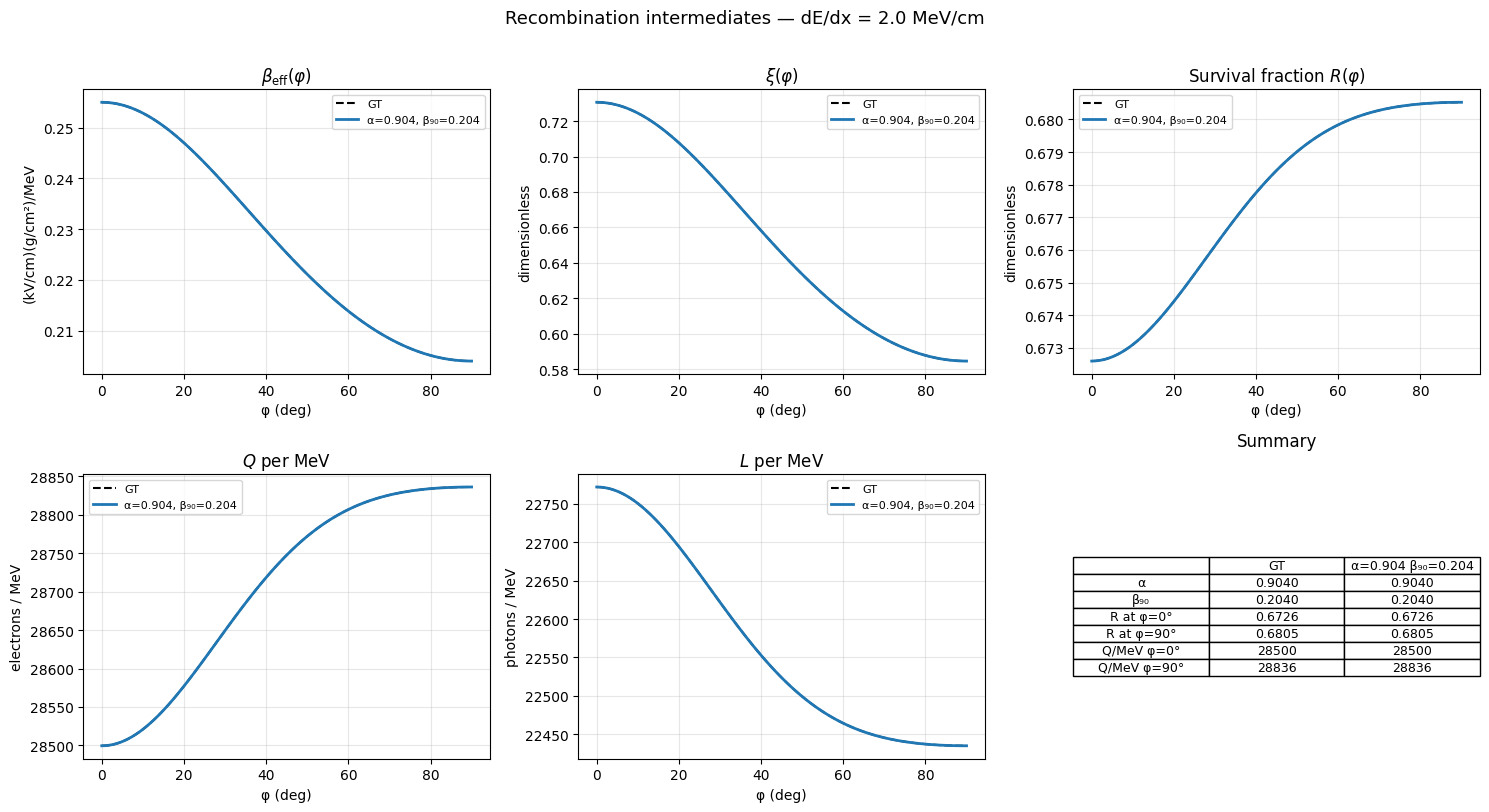

In [ ]:
# ── Edit these ────────────────────────────────────────────────────────────────
ALPHA   = float(rp_gt.alpha)    # try e.g. 0.7, 1.1
BETA_90 = float(rp_gt.beta_90) # try e.g. 0.15, 0.25
DE_DX   = 2.0   # MeV/cm (typical MIP: ~2 MeV/cm)
# ─────────────────────────────────────────────────────────────────────────────

gt_mid  = recomb_intermediates(float(rp_gt.alpha), float(rp_gt.beta_90), de_dx_MeV_cm=DE_DX)
result  = recomb_intermediates(ALPHA, BETA_90, de_dx_MeV_cm=DE_DX)

phi = result['phi_deg']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

specs = [
    ('beta_eff',  r'$\beta_\mathrm{eff}(\varphi)$',  '(kV/cm)(g/cm²)/MeV'),
    ('xi',        r'$\xi(\varphi)$',                  'dimensionless'),
    ('R',         r'Survival fraction $R(\varphi)$',   'dimensionless'),
    ('Q_per_MeV', r'$Q$ per MeV',                      'electrons / MeV'),
    ('L_per_MeV', r'$L$ per MeV',                      'photons / MeV'),
]

for ax, (key, label, unit) in zip(axes[:5], specs):
    ax.plot(phi, gt_mid[key],  'k--', lw=1.5, label='GT')
    ax.plot(phi, result[key],  'C0',  lw=2.0,
            label=f'α={ALPHA:.3f}, β₉₀={BETA_90:.3f}')
    ax.set_xlabel('φ (deg)')
    ax.set_ylabel(unit)
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Summary table in the last panel
ax = axes[5]
ax.axis('off')
rows = [
    ['', 'GT', f'α={ALPHA:.3f} β₉₀={BETA_90:.3f}'],
    ['α',       f"{float(rp_gt.alpha):.4f}",   f"{ALPHA:.4f}"],
    ['β₉₀',     f"{float(rp_gt.beta_90):.4f}", f"{BETA_90:.4f}"],
    ['R at φ=0°',   f"{gt_mid['R'][0]:.4f}",  f"{result['R'][0]:.4f}"],
    ['R at φ=90°',  f"{gt_mid['R'][-1]:.4f}", f"{result['R'][-1]:.4f}"],
    ['Q/MeV φ=0°',  f"{gt_mid['Q_per_MeV'][0]:.0f}",  f"{result['Q_per_MeV'][0]:.0f}"],
    ['Q/MeV φ=90°', f"{gt_mid['Q_per_MeV'][-1]:.0f}", f"{result['Q_per_MeV'][-1]:.0f}"],
]
tbl = ax.table(cellText=rows[1:], colLabels=rows[0], loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
ax.set_title('Summary', pad=20)

fig.suptitle(
    f'Recombination intermediates — dE/dx = {DE_DX} MeV/cm',
    fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Full simulation loss

`compute_loss(alpha, beta_90)` runs a forward pass through the full detector simulator
and returns both Sobolev losses relative to the GT forward pass (run at cell 4).

Vary `alpha` and `beta_90` below.

W0419 23:40:22.468041   30946 pjrt_executable.cc:642] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


sobolev loss       : 1.102141e-11
sobolev log1p loss : 1.836901e-12
per-plane sobolev  : ['0.000e+00', '0.000e+00', '0.000e+00', '8.273e-13', '6.944e-12', '3.250e-12']


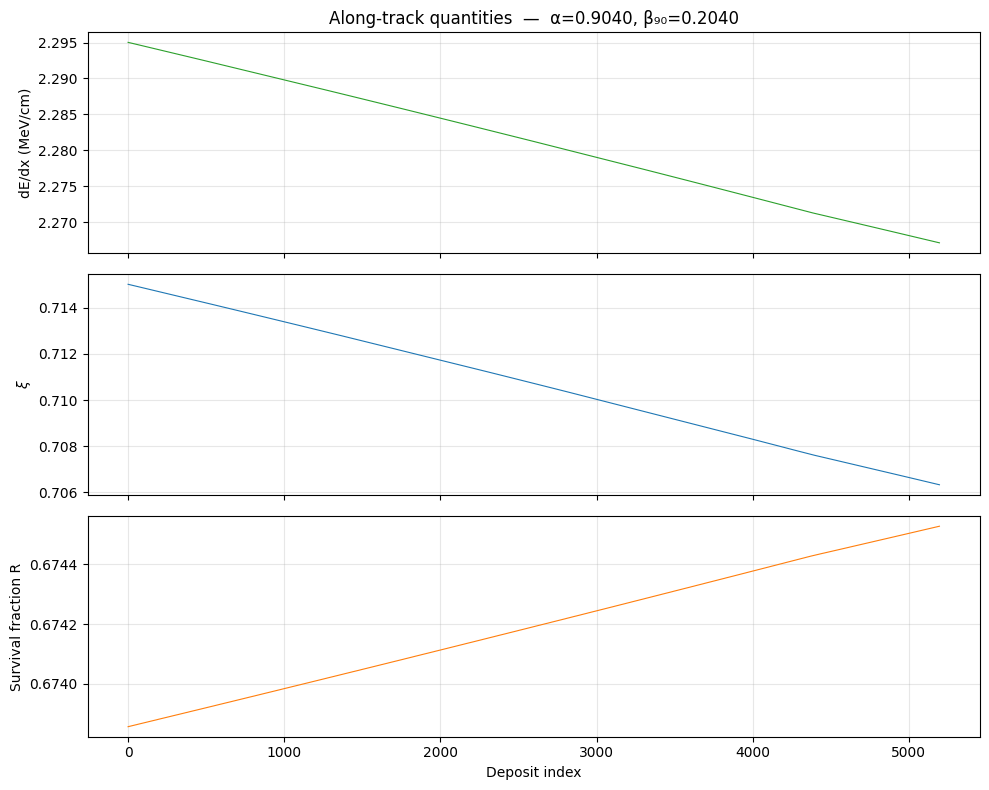

In [ ]:
# ── Your turn — vary alpha and beta_90 ────────────────────────────────────────
ALPHA   = float(rp_gt.alpha)
BETA_90 = float(rp_gt.beta_90)

result = compute_loss(alpha=ALPHA, beta_90=BETA_90)

print(f"sobolev loss       : {result['sobolev']:.6e}")
print(f"sobolev log1p loss : {result['sobolev_log1p']:.6e}")
print(f"per-plane sobolev  : {[f'{v:.3e}' for v in result['per_plane_sobolev']]}")

# ── Plot ξ along the track ─────────────────────────────────────────────────────
deposit_idx = np.arange(len(result['xi']))

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(deposit_idx, result['de_dx'], lw=0.8, color='C2')
axes[0].set_ylabel('dE/dx (MeV/cm)')
axes[0].set_title(f'Along-track quantities  —  α={ALPHA:.4f}, β₉₀={BETA_90:.4f}')
axes[0].grid(True, alpha=0.3)

axes[1].plot(deposit_idx, result['xi'], lw=0.8, color='C0')
axes[1].set_ylabel(r'$\xi$')
axes[1].grid(True, alpha=0.3)

axes[2].plot(deposit_idx, result['R'], lw=0.8, color='C1')
axes[2].set_ylabel('Survival fraction R')
axes[2].set_xlabel('Deposit index')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
track_phi_deg = np.degrees(track["phi"][0])
print(f"Track angle φ: {track_phi_deg:.1f}°")

Track angle φ: 45.0°
